# 01 Single Bus Simulation

This notebook follows one representative bus block from the frozen `all_blocks.parquet` table into a multi-day-safe SOC simulation. It is deliberately honest about what the GTFS-derived table can and cannot say: native blocks are cleaner than inferred blocks, shape distance is not always available, depot charging is still a terminus abstraction, and there is no calendar-aware service day yet.

In [52]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_START = time.time()
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "mobility").exists() else NOTEBOOK_DIR
if not (REPO_ROOT / "mobility").exists():
    REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from mobility.core import DailySchedule, ParkingEvent, Trip, simulate_single_day
from mobility.core.constants import CV_THRESHOLD, DEFAULT_CHEMISTRY
from mobility.core.simulator import STEP_HOURS, STEPS_PER_DAY
from mobility.bus.data_loader import attach_lsoa, load_all_blocks, summarize_block_quality
from mobility.bus.selection import (
    render_block_identity_card,
    sample_contrast_block,
    sample_protagonist_block,
)
from mobility.bus.trip_chain_bus import block_to_daily_schedules
from mobility.bus.sim_adapter import simulate_block, simulate_fleet_blocks
from mobility.bus.vehicle_sampling import load_bus_vehicle_params, sample_bus_vehicle_specs

BLOCKS_PATH = REPO_ROOT / "outputs" / "all_blocks.parquet"
AUDIT_PATH = REPO_ROOT / "outputs" / "bus_feasibility_audit.parquet"
VEHICLE_PARAMS_PATH = REPO_ROOT.parent / "Data" / "EV" / "EV_prepared" / "BEV_Bus_Coach_unique_with_params_with_AC.csv"
MAIN_BUS_SEED = 20260430
ALT_BUS_SEED = MAIN_BUS_SEED + 1
VEHICLE_SEED = MAIN_BUS_SEED + 2
FALLBACK_BUS_BATTERY_KWH = 300.0
FALLBACK_BUS_CONSUMPTION_KWH_PER_KM = 1.2
FALLBACK_DEPOT_CHARGE_KW = 100.0

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 0. Units & time grid

,metric,value
0,SOC steps,96.000000
1,load steps,96.000000
2,STEP_HOURS,0.250000
3,load_kw x STEP_HOURS,239.992810
4,session energy_kwh,239.992810
5,soc_end,0.999976


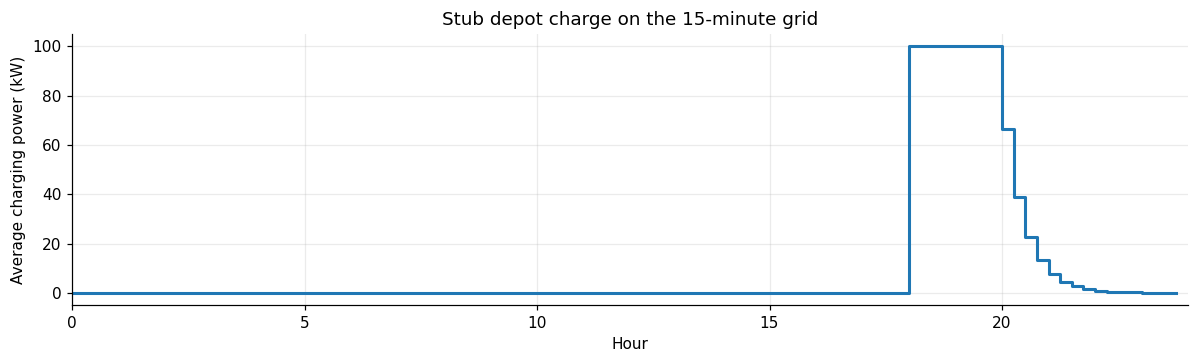

In [53]:
stub_schedule = DailySchedule(
    ev_id="bus_stage0_stub",
    day=0,
    day_type="representative_service_day",
    parking_events=[
        ParkingEvent(
            start_time=0.0,
            end_time=18.0,
            duration_hours=18.0,
            location_purpose="depot_terminus",
            can_charge=False,
            charge_power_kw=0.0,
        ),
        ParkingEvent(
            start_time=18.0,
            end_time=24.0,
            duration_hours=6.0,
            location_purpose="depot_terminus",
            can_charge=True,
            charge_power_kw=100.0,
        ),
    ],
)
stub_soc, stub_load_kw, stub_soc_end = simulate_single_day(
    stub_schedule,
    battery_capacity_kwh=300.0,
    soc_start=0.20,
)
unit_check = pd.DataFrame(
    [
        ("SOC steps", len(stub_soc)),
        ("load steps", len(stub_load_kw)),
        ("STEP_HOURS", STEP_HOURS),
        ("load_kw x STEP_HOURS", float(stub_load_kw.sum() * STEP_HOURS)),
        ("session energy_kwh", sum(event.energy_charged_kwh for event in stub_schedule.parking_events)),
        ("soc_end", stub_soc_end),
    ],
    columns=["metric", "value"],
)
display(unit_check)

hours = np.arange(STEPS_PER_DAY) * STEP_HOURS
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.step(hours, stub_load_kw, where="post", color="tab:blue", lw=2)
ax.set(xlabel="Hour", ylabel="Average charging power (kW)", title="Stub depot charge on the 15-minute grid")
ax.set_xlim(0, 24)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 0.5 One-step-at-a-time physics

Stage 0 runs `simulate_single_day` as a black box. This stage opens it.

The simulator works on a 96-step / 15-minute decision grid. Three
mechanics decide every SOC trace:

1. **Trip energy is spread across overlapping steps**, not deposited at
   the trip's start. A 30-minute trip starting at 8:05 contributes to
   steps 32 (08:00-08:15) and 33 (08:15-08:30) in proportion to overlap.
2. **Charging follows a CC-CV approximation**. Below the CV threshold
   (default 0.80) the simulator draws full power; above it, power
   tapers linearly to zero at SOC=1.0.
3. **SOC clamps to zero on infeasibility**. If a step's discharge
   drives SOC below zero, the simulator silently dams it at zero and
   keeps going. The `load_kw` you see afterwards is wrong, but no
   exception is raised. (`mobility.coach.feasibility` exists exactly
   to wall this off upstream.)

Stage 0.5 builds three minimum-viable schedules to make each mechanic
visible.

### 0.5a Trip energy and parking power on the 15-minute grid

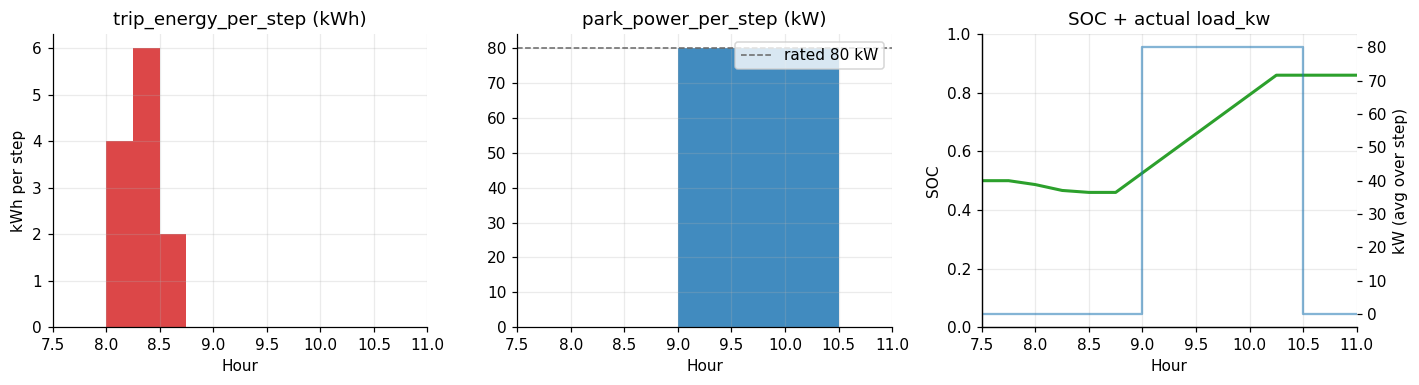

,metric,value
0,trip duration_h,0.5
1,rate_per_hour kWh/h,24.0
2,sum trip_energy_per_step,12.0
3,trip energy_consumed_kwh,12.0
4,steps with trip_energy > 0,3.0
5,max park_power_per_step (kW),80.0
6,rated charge_power_kw,80.0


In [68]:
from mobility.core.simulator import _STEP_STARTS, _STEP_ENDS

demo_trip = Trip(
    trip_id="demo",
    departure_time=8.0833,
    arrival_time=8.5833,
    distance_km=10.0,
    origin_purpose="bus_stop",
    destination_purpose="bus_stop",
    energy_consumed_kwh=10.0 * 1.2,
)
demo_park = ParkingEvent(
    start_time=9.0,
    end_time=10.5,
    duration_hours=1.5,
    location_purpose="depot_terminus",
    can_charge=True,
    charge_power_kw=80.0,
)
demo_schedule = DailySchedule(
    ev_id="demo_grid",
    day=0,
    day_type="representative_service_day",
    trips=[demo_trip],
    parking_events=[demo_park],
)

trip_overlap_h = np.maximum(
    0.0,
    np.minimum(_STEP_ENDS, demo_trip.arrival_time)
    - np.maximum(_STEP_STARTS, demo_trip.departure_time),
)
rate_per_hour = demo_trip.energy_consumed_kwh / (
    demo_trip.arrival_time - demo_trip.departure_time
)
trip_energy_per_step = trip_overlap_h * rate_per_hour

park_overlap_h = np.maximum(
    0.0,
    np.minimum(_STEP_ENDS, demo_park.end_time)
    - np.maximum(_STEP_STARTS, demo_park.start_time),
)
park_power_per_step = demo_park.charge_power_kw * (park_overlap_h / STEP_HOURS)

demo_soc, demo_load_kw, _ = simulate_single_day(
    demo_schedule,
    battery_capacity_kwh=300.0,
    soc_start=0.50,
)
hours = np.arange(STEPS_PER_DAY) * STEP_HOURS

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
axes[0].bar(hours, trip_energy_per_step, width=STEP_HOURS, align="edge", color="tab:red", alpha=0.85)
axes[0].set(title="trip_energy_per_step (kWh)", xlabel="Hour", ylabel="kWh per step")
axes[0].set_xlim(7.5, 11.0)
axes[0].grid(alpha=0.25)

axes[1].bar(hours, park_power_per_step, width=STEP_HOURS, align="edge", color="tab:blue", alpha=0.85)
axes[1].axhline(demo_park.charge_power_kw, color="0.4", ls="--", lw=1, label="rated 80 kW")
axes[1].set(title="park_power_per_step (kW)", xlabel="Hour")
axes[1].set_xlim(7.5, 11.0)
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.25)

ax_soc = axes[2]
ax_load = ax_soc.twinx()
ax_soc.plot(hours, demo_soc, color="tab:green", lw=2, label="SOC")
ax_load.step(hours, demo_load_kw, where="post", color="tab:blue", alpha=0.55, label="load_kw")
ax_soc.set(title="SOC + actual load_kw", xlabel="Hour", ylabel="SOC", ylim=(0.0, 1.0))
ax_load.set_ylabel("kW (avg over step)")
ax_soc.set_xlim(7.5, 11.0)
ax_soc.grid(alpha=0.25)
plt.tight_layout()
plt.show()

grid_audit = pd.DataFrame(
    [
        ("trip duration_h", demo_trip.arrival_time - demo_trip.departure_time),
        ("rate_per_hour kWh/h", rate_per_hour),
        ("sum trip_energy_per_step", float(trip_energy_per_step.sum())),
        ("trip energy_consumed_kwh", demo_trip.energy_consumed_kwh),
        ("steps with trip_energy > 0", int((trip_energy_per_step > 0).sum())),
        ("max park_power_per_step (kW)", float(park_power_per_step.max())),
        ("rated charge_power_kw", demo_park.charge_power_kw),
    ],
    columns=["metric", "value"],
)
display(grid_audit)

### 0.5b CC-CV charge taper in isolation

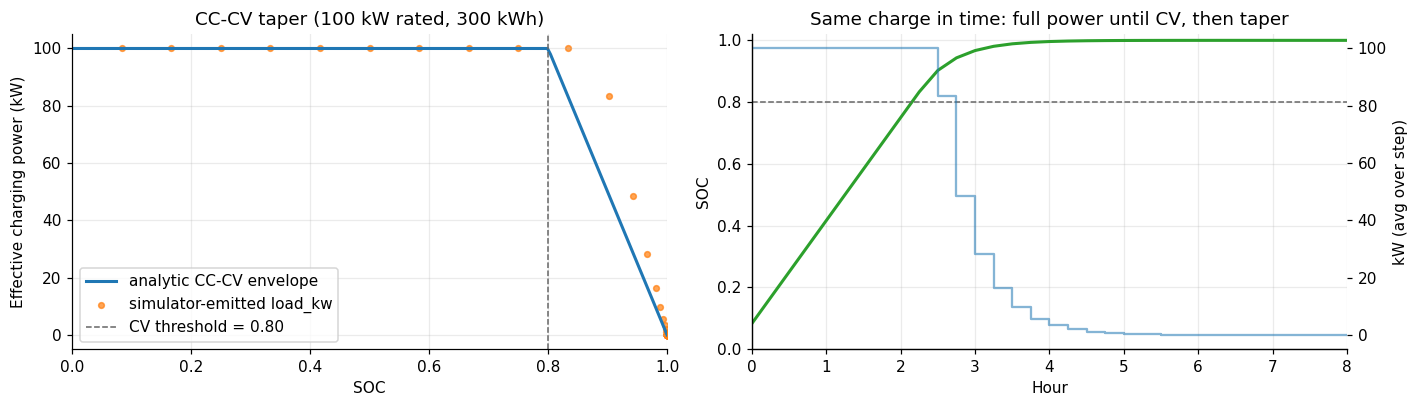

,metric,value
0,cv_threshold,0.800000
1,rated_kw,100.000000
2,battery_kwh,300.000000
3,hours to reach SOC=cv_threshold,2.250000
4,hours to reach SOC>=0.99,3.750000
5,load_kw at SOC=0.95 (approx),28.356481


In [69]:
from mobility.core.simulator import _soc_walk

cv_threshold = CV_THRESHOLD[DEFAULT_CHEMISTRY]
battery_kwh = 300.0
rated_kw = 100.0
n_steps = STEPS_PER_DAY

trip_zero = np.zeros(n_steps, dtype=float)
park_full = np.full(n_steps, rated_kw, dtype=float)
soc_out = np.zeros(n_steps, dtype=float)
load_out = np.zeros(n_steps, dtype=float)

_soc_walk(
    trip_zero,
    park_full,
    battery_kwh,
    0.0,
    soc_out,
    load_out,
    cv_threshold,
)
hours = np.arange(n_steps) * STEP_HOURS

soc_grid = np.linspace(0.0, 1.0, 200)
analytic_factor = np.where(soc_grid < cv_threshold, 1.0, (1.0 - soc_grid) / (1.0 - cv_threshold))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

ax = axes[0]
ax.plot(soc_grid, analytic_factor * rated_kw, color="tab:blue", lw=2, label="analytic CC-CV envelope")
ax.scatter(soc_out, load_out, color="tab:orange", s=14, alpha=0.7, label="simulator-emitted load_kw")
ax.axvline(cv_threshold, color="0.4", ls="--", lw=1, label=f"CV threshold = {cv_threshold:.2f}")
ax.set(xlabel="SOC", ylabel="Effective charging power (kW)", title=f"CC-CV taper ({rated_kw:.0f} kW rated, {battery_kwh:.0f} kWh)")
ax.set_xlim(0, 1)
ax.grid(alpha=0.25)
ax.legend(loc="lower left")

ax = axes[1]
ax_load = ax.twinx()
ax.plot(hours, soc_out, color="tab:green", lw=2, label="SOC")
ax_load.step(hours, load_out, where="post", color="tab:blue", alpha=0.55, label="load_kw")
ax.axhline(cv_threshold, color="0.4", ls="--", lw=1, label="CV threshold")
ax.set(xlabel="Hour", ylabel="SOC", title="Same charge in time: full power until CV, then taper", ylim=(0, 1.02))
ax_load.set_ylabel("kW (avg over step)")
ax.set_xlim(0, 8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

cv_summary = pd.DataFrame(
    [
        ("cv_threshold", cv_threshold),
        ("rated_kw", rated_kw),
        ("battery_kwh", battery_kwh),
        ("hours to reach SOC=cv_threshold", float(np.argmax(soc_out >= cv_threshold) * STEP_HOURS)),
        ("hours to reach SOC>=0.99", float(np.argmax(soc_out >= 0.99) * STEP_HOURS) if (soc_out >= 0.99).any() else float("nan")),
        ("load_kw at SOC=0.95 (approx)", float(load_out[np.searchsorted(soc_out, 0.95)]) if (soc_out >= 0.95).any() else float("nan")),
    ],
    columns=["metric", "value"],
)
display(cv_summary)

### 0.5c Silent SOC-floor clamp on an infeasible day

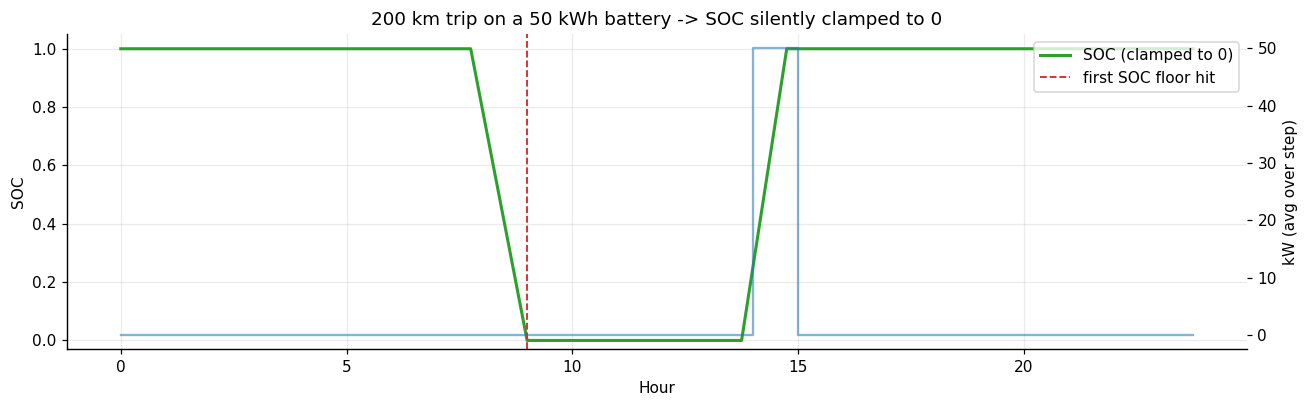

,metric,value
0,battery_kwh,50.0
1,required_kwh (distance x consumption),240.0
2,usable_kwh (no safety margin),50.0
3,shortfall_kwh,190.0
4,first_floor_hit_h,9.0
5,simulator soc_end (do not trust),1.0
6,simulator total_charged_kwh,50.0


In [56]:
infeasible_trip = Trip(
    trip_id="too_long",
    departure_time=8.0,
    arrival_time=14.0,
    distance_km=200.0,
    origin_purpose="bus_stop",
    destination_purpose="bus_stop",
    energy_consumed_kwh=200.0 * 1.2,
)
infeasible_schedule = DailySchedule(
    ev_id="demo_infeasible",
    day=0,
    day_type="representative_service_day",
    trips=[infeasible_trip],
    parking_events=[
        ParkingEvent(0.0, 8.0, 8.0, "depot_terminus", can_charge=True, charge_power_kw=0.0),
        ParkingEvent(14.0, 24.0, 10.0, "depot_terminus", can_charge=True, charge_power_kw=50.0),
    ],
)
small_battery_kwh = 50.0
consumption_kwh_per_km = 1.2
usable_kwh = small_battery_kwh
required_kwh = infeasible_trip.distance_km * consumption_kwh_per_km

bad_soc, bad_load_kw, bad_soc_end = simulate_single_day(
    infeasible_schedule,
    battery_capacity_kwh=small_battery_kwh,
    soc_start=1.0,
)
hours = np.arange(STEPS_PER_DAY) * STEP_HOURS
first_floor_step = int(np.argmax(bad_soc <= 1e-9)) if (bad_soc <= 1e-9).any() else -1

fig, ax = plt.subplots(figsize=(12, 3.8))
ax_load = ax.twinx()
ax.plot(hours, bad_soc, color="tab:green", lw=2, label="SOC (clamped to 0)")
ax_load.step(hours, bad_load_kw, where="post", color="tab:blue", alpha=0.55, label="load_kw")
if first_floor_step >= 0:
    ax.axvline(first_floor_step * STEP_HOURS, color="tab:red", ls="--", lw=1.2, label="first SOC floor hit")
ax.set(xlabel="Hour", ylabel="SOC", ylim=(-0.03, 1.05), title="200 km trip on a 50 kWh battery -> SOC silently clamped to 0")
ax_load.set_ylabel("kW (avg over step)")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

clamp_audit = pd.DataFrame(
    [
        ("battery_kwh", small_battery_kwh),
        ("required_kwh (distance x consumption)", required_kwh),
        ("usable_kwh (no safety margin)", usable_kwh),
        ("shortfall_kwh", max(0.0, required_kwh - usable_kwh)),
        ("first_floor_hit_h", float(first_floor_step * STEP_HOURS) if first_floor_step >= 0 else float("nan")),
        ("simulator soc_end (do not trust)", float(bad_soc_end)),
        ("simulator total_charged_kwh", float(bad_load_kw.sum() * STEP_HOURS)),
    ],
    columns=["metric", "value"],
)
display(clamp_audit)

## A. What `all_blocks.parquet` is

,value
n_blocks,2.149150e+05
n_trips,1.668452e+06
pct_native,4.130517e+01
pct_inferred,5.869483e+01
pct_shape_distance,4.662885e+01
pct_stop_haversine_distance,5.337115e+01
stop_continuity_native,7.330800e+01
stop_continuity_inferred,4.474245e+01
pct_cross_midnight_blocks,1.159296e+01
layover_h_p50,1.333332e-01


,metric,value
0,join_method,polygon_with_centroid_fallback
1,max_distance_km,5.0
2,n_unmatched_rows,2237
3,pct_rows_unmatched,0.134076
4,polygon_pct,99.139921
5,centroid_fallback_pct,0.773861
6,no_match_pct,0.086218
7,source_breakdown,"{'EW_LSOA21': 86.86716788975649, 'Scotland_DZ2..."
8,start_distance_km_median,0.0
9,start_distance_km_p99,0.0


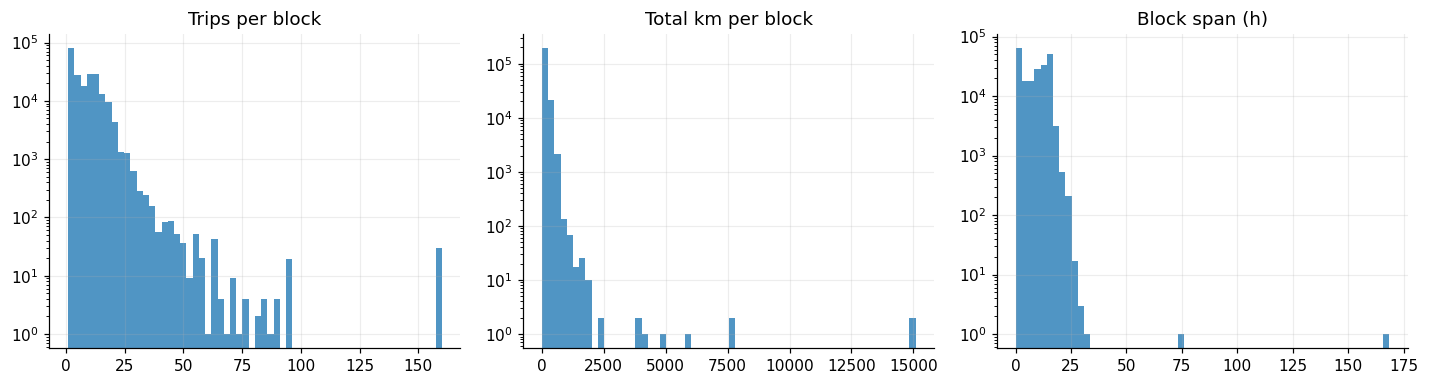

In [57]:
all_blocks = attach_lsoa(load_all_blocks(BLOCKS_PATH))
quality = summarize_block_quality(all_blocks)
display(quality.T.rename(columns={0: "value"}))

lsoa_join = all_blocks.attrs["lsoa_join"]
matched_start = all_blocks["start_lsoa"].ne("")
matched_end = all_blocks["end_lsoa"].ne("")
lsoa_qc = pd.DataFrame(
    [
        ("join_method", lsoa_join.get("method", "centroid_fallback")),
        ("max_distance_km", lsoa_join["max_distance_km"]),
        ("n_unmatched_rows", lsoa_join["n_unmatched"]),
        ("pct_rows_unmatched", 100.0 * lsoa_join["n_unmatched"] / max(len(all_blocks), 1)),
        ("polygon_pct", lsoa_join.get("polygon_pct", np.nan)),
        ("centroid_fallback_pct", lsoa_join.get("centroid_fallback_pct", np.nan)),
        ("no_match_pct", lsoa_join.get("no_match_pct", np.nan)),
        ("source_breakdown", lsoa_join.get("source_breakdown", {})),
        ("start_distance_km_median", all_blocks.loc[matched_start, "start_lsoa_distance_km"].median()),
        ("start_distance_km_p99", all_blocks.loc[matched_start, "start_lsoa_distance_km"].quantile(0.99)),
        ("end_distance_km_median", all_blocks.loc[matched_end, "end_lsoa_distance_km"].median()),
        ("end_distance_km_p99", all_blocks.loc[matched_end, "end_lsoa_distance_km"].quantile(0.99)),
    ],
    columns=["metric", "value"],
)
display(lsoa_qc)

block_stats = all_blocks.groupby("block_id").agg(
    n_trips=("trip_id", "count"),
    total_km=("distance_km", "sum"),
    start_h=("start_h", "min"),
    end_h=("end_h", "max"),
    block_source=("block_source", "first"),
)
block_stats["span_h"] = block_stats["end_h"] - block_stats["start_h"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, title in zip(
    axes,
    ["n_trips", "total_km", "span_h"],
    ["Trips per block", "Total km per block", "Block span (h)"],
):
    ax.hist(block_stats[col], bins=60, color="tab:blue", alpha=0.78)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.grid(alpha=0.22)
plt.tight_layout()
plt.show()

## A.1. Trip endpoint LSOAs

LSOA/Data Zone assignment now uses polygon-with-centroid-fallback: points inside EW LSOA21 / Scotland DZ2022 / NI DZ2021 polygons use polygon match; offshore or unmatched points fall back to the legacy nearest-centroid method. The join is event-level: trips get origin and destination small-area codes, layovers inherit the previous trip's destination, and first/last depot dwell uses the surrounding trip endpoint.

## A.5. Honest labels for the data

In [58]:
q = quality.iloc[0]
honest_labels = pd.DataFrame(
    [
        ("Cross-midnight blocks", f"{q['pct_cross_midnight_blocks']:.1f}% of blocks have end_h >= 24", "Handled by splitting into day 0 and day 1 schedules."),
        ("Native vs inferred continuity", f"native {q['stop_continuity_native']:.1f}% / inferred {q['stop_continuity_inferred']:.1f}%", "Selection defaults to native; inferred quality is still reported."),
        ("Distance provenance", f"shape {q['pct_shape_distance']:.1f}% / stop_haversine {q['pct_stop_haversine_distance']:.1f}%", "Stop-haversine distance is a transparent fallback and likely underestimates by 15-25%."),
        ("Endpoint LSOAs", "nearest LSOA-21 centroid join, 5 km threshold", "Scotland / NI / offshore stops can stay empty; distance_km columns expose the QC."),
        ("Depot abstraction", "depot_terminus", "It marks first/last terminus dwell, not a real depot model."),
        ("Layover LSOA convention", "previous trip end_lsoa", "The location marks where the bus is parked, not where it heads next."),
        ("Vehicle subtype filter", "include={bus, minibus, unknown}", "Coach GenModels and obvious misclassifications are filtered at load time using Data/EV/manual/genmodel_subtype_lookup.csv."),
        ("Calendar missing", "service_id only", "The label is a representative service day, never a real date."),
    ],
    columns=["issue", "observed label", "notebook treatment"],
)
display(honest_labels)

,issue,observed label,notebook treatment
0,Cross-midnight blocks,11.6% of blocks have end_h >= 24,Handled by splitting into day 0 and day 1 sche...
1,Native vs inferred continuity,native 73.3% / inferred 44.7%,Selection defaults to native; inferred quality...
2,Distance provenance,shape 46.6% / stop_haversine 53.4%,Stop-haversine distance is a transparent fallb...
3,Endpoint LSOAs,"nearest LSOA-21 centroid join, 5 km threshold",Scotland / NI / offshore stops can stay empty;...
4,Depot abstraction,depot_terminus,"It marks first/last terminus dwell, not a real..."
5,Layover LSOA convention,previous trip end_lsoa,"The location marks where the bus is parked, no..."
6,Vehicle subtype filter,"include={bus, minibus, unknown}",Coach GenModels and obvious misclassifications...
7,Calendar missing,service_id only,"The label is a representative service day, nev..."


## B. Picking a protagonist

In [59]:
main_rng = np.random.default_rng(MAIN_BUS_SEED)
alt_rng = np.random.default_rng(ALT_BUS_SEED)
protagonist_id = sample_protagonist_block(all_blocks, main_rng)
contrast_id = sample_contrast_block(all_blocks, alt_rng, protagonist_id)

protagonist_card = render_block_identity_card(all_blocks, protagonist_id)
contrast_card = render_block_identity_card(all_blocks, contrast_id)
display(pd.concat([protagonist_card.assign(role="protagonist"), contrast_card.assign(role="contrast")], ignore_index=True))

vehicle_params = load_bus_vehicle_params(VEHICLE_PARAMS_PATH, fallback_depot_charge_kw=FALLBACK_DEPOT_CHARGE_KW)
vehicle_rng = np.random.default_rng(VEHICLE_SEED)
protagonist_vehicle = sample_bus_vehicle_specs(vehicle_params, vehicle_rng, n=1).iloc[0]
BUS_BATTERY_KWH = float(protagonist_vehicle["battery_kwh"])
BUS_CONSUMPTION_KWH_PER_KM = float(protagonist_vehicle["consumption_kwh_per_km"])
DEPOT_CHARGE_KW = float(protagonist_vehicle["depot_charge_kw"])

vehicle_summary = pd.DataFrame(
    [
        ("source rows", vehicle_params.attrs["input_rows"]),
        ("sampling rows", vehicle_params.attrs["sampling_rows"]),
        ("stock coverage", f"{vehicle_params.attrs['stock_coverage_pct']:.1f}%"),
        ("sampled make", protagonist_vehicle["make"]),
        ("sampled model", protagonist_vehicle["gen_model"]),
        ("subtype filter", ", ".join(vehicle_params.attrs.get("include_subtypes", ()))),
        ("dropped by subtype", str(vehicle_params.attrs.get("dropped_by_subtype", {}))),
        ("sampled subtype", str(protagonist_vehicle.get("subtype", ""))),
        ("battery_kwh", BUS_BATTERY_KWH),
        ("consumption_kwh_per_km", BUS_CONSUMPTION_KWH_PER_KM),
        ("depot_charge_kw", DEPOT_CHARGE_KW),
    ],
    columns=["metric", "value"],
)
display(vehicle_summary)

,block_id,agency_id,n_trips,total_km,span_h,service_id,distance_source_breakdown,stop_continuity,n_routes,service_day_label,role
0,96ecdc100da3a3a41b0b5d57e89d4ae12380c450,OP393,11,137.868103,5.466666,5847,shape=100.0%,0.500000,1,a representative service day,protagonist
1,d40493e37a9fb5372a7c2551f60906cd95573274,OP772,24,302.075409,17.066668,12508,shape=100.0%,0.478261,2,a representative service day,contrast


,metric,value
0,source rows,32
1,sampling rows,14
2,stock coverage,93.0%
3,sampled make,BYD
4,sampled model,BYD EBUS
5,subtype filter,"bus, minibus, unknown"
6,dropped by subtype,{'coach': 3}
7,sampled subtype,bus
8,battery_kwh,345.0
9,consumption_kwh_per_km,0.83


## C. Block -> schedule

,day,trip_id,route_id,departure_h,arrival_h,distance_km,energy_kwh,origin_lsoa,destination_lsoa
0,0,VJ42cff7261573bbd348dfc9b5c0fd153321691c49__d0,60001,9.416667,9.883333,12.430995,10.317726,E01021490,E01021520
1,0,VJ51e93d0ad8eb39c7408976f5177e0846293254e4__d0,60001,9.900000,10.366667,12.656425,10.504833,E01021520,E01021490
2,0,VJ4ceb4881d42d08f1ea785a16a7697dcdd1b2ccc9__d0,60001,10.416667,10.883333,12.430995,10.317726,E01021490,E01021520
3,0,VJ2bb89fcf8e4cf95feb04d899473565b8bb7f877f__d0,60001,10.900000,11.366667,12.656425,10.504833,E01021520,E01021490
4,0,VJd6a848fcf31f42ed271d31df1af4ce992caa687f__d0,60001,11.416667,11.883333,12.430995,10.317726,E01021490,E01021520
5,0,VJ3e1aaa999eb24ea872c6dfe78ee27f17fb214f32__d0,60001,11.900000,12.366667,12.656425,10.504833,E01021520,E01021490
6,0,VJa39a12b06e912fb61481a86f20a404d64859894f__d0,60001,12.416667,12.883333,12.430995,10.317726,E01021490,E01021520
7,0,VJba8d2bcc9a70b009f5b34f617f3c291e0117cc5d__d0,60001,12.900000,13.366667,12.656425,10.504833,E01021520,E01021490
8,0,VJ6a46ac5cb5ff5ec7a001e99b64c841fdcdc5714c__d0,60001,13.416667,13.883333,12.430995,10.317726,E01021490,E01021520
9,0,VJbb9544149024cc8dbb4b89f7d8517d65e2e1c67c__d0,60001,13.900000,14.366667,12.656425,10.504833,E01021520,E01021490


,day,purpose,start_h,end_h,duration_h,location_lsoa,can_charge,charge_power_kw
0,0,depot_terminus,0.000000,9.416667,9.416667,E01021490,True,100.0
1,0,layover,9.883333,9.900000,0.016666,E01021520,False,0.0
2,0,layover,10.366667,10.416667,0.050000,E01021490,False,0.0
3,0,layover,10.883333,10.900000,0.016666,E01021520,False,0.0
4,0,layover,11.366667,11.416667,0.050000,E01021490,False,0.0
5,0,layover,11.883333,11.900000,0.016666,E01021520,False,0.0
6,0,layover,12.366667,12.416667,0.050000,E01021490,False,0.0
7,0,layover,12.883333,12.900000,0.016666,E01021520,False,0.0
8,0,layover,13.366667,13.416667,0.050000,E01021490,False,0.0
9,0,layover,13.883333,13.900000,0.016666,E01021520,False,0.0


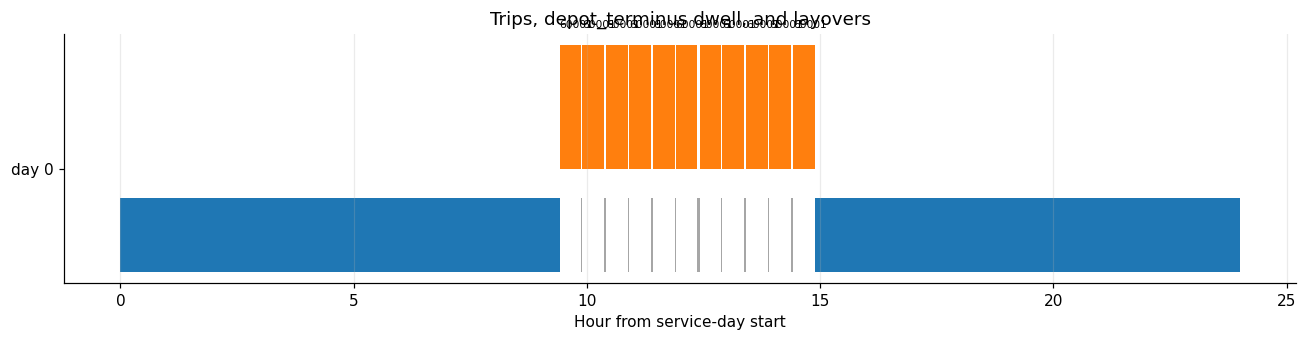

In [60]:
protagonist_block = all_blocks[all_blocks["block_id"].astype(str) == protagonist_id].copy()
schedules = block_to_daily_schedules(
    protagonist_block,
    ev_id=f"bus_{protagonist_id}",
    consumption_kwh_per_km=BUS_CONSUMPTION_KWH_PER_KM,
    depot_charge_kw=DEPOT_CHARGE_KW,
)

trip_rows = []
parking_rows = []
for schedule in schedules:
    day_offset = schedule.day * 24.0
    for trip in schedule.trips:
        trip_rows.append(
            {
                "day": schedule.day,
                "trip_id": trip.trip_id,
                "route_id": getattr(trip, "route_id", ""),
                "departure_h": trip.departure_time,
                "arrival_h": trip.arrival_time,
                "distance_km": trip.distance_km,
                "energy_kwh": trip.energy_consumed_kwh,
                "origin_lsoa": trip.origin_lsoa,
                "destination_lsoa": trip.destination_lsoa,
            }
        )
    for event in schedule.parking_events:
        parking_rows.append(
            {
                "day": schedule.day,
                "purpose": event.location_purpose,
                "start_h": event.start_time,
                "end_h": event.end_time,
                "duration_h": event.duration_hours,
                "location_lsoa": event.location_lsoa,
                "can_charge": event.can_charge,
                "charge_power_kw": event.charge_power_kw,
            }
        )

trips_table = pd.DataFrame(trip_rows)
parking_table = pd.DataFrame(parking_rows)
display(trips_table.head(20))
display(parking_table.head(20))

fig, ax = plt.subplots(figsize=(12, max(3.2, len(schedules) * 1.8)))
colors = {"trip": "tab:orange", "depot_terminus": "tab:blue", "layover": "0.65"}
y = 0
for schedule in schedules:
    for event in schedule.parking_events:
        ax.broken_barh([(schedule.day * 24 + event.start_time, event.duration_hours)], (y - 0.35, 0.25), facecolors=colors[event.location_purpose])
    for trip in schedule.trips:
        ax.broken_barh([(schedule.day * 24 + trip.departure_time, trip.arrival_time - trip.departure_time)], (y, 0.42), facecolors=colors["trip"])
        ax.text(schedule.day * 24 + trip.departure_time, y + 0.48, str(getattr(trip, "route_id", "")), fontsize=7)
    y += 1
ax.set_yticks(range(len(schedules)))
ax.set_yticklabels([f"day {schedule.day}" for schedule in schedules])
ax.set_xlabel("Hour from service-day start")
ax.set_title("Trips, depot_terminus dwell, and layovers")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## D. Baseline SOC trajectory

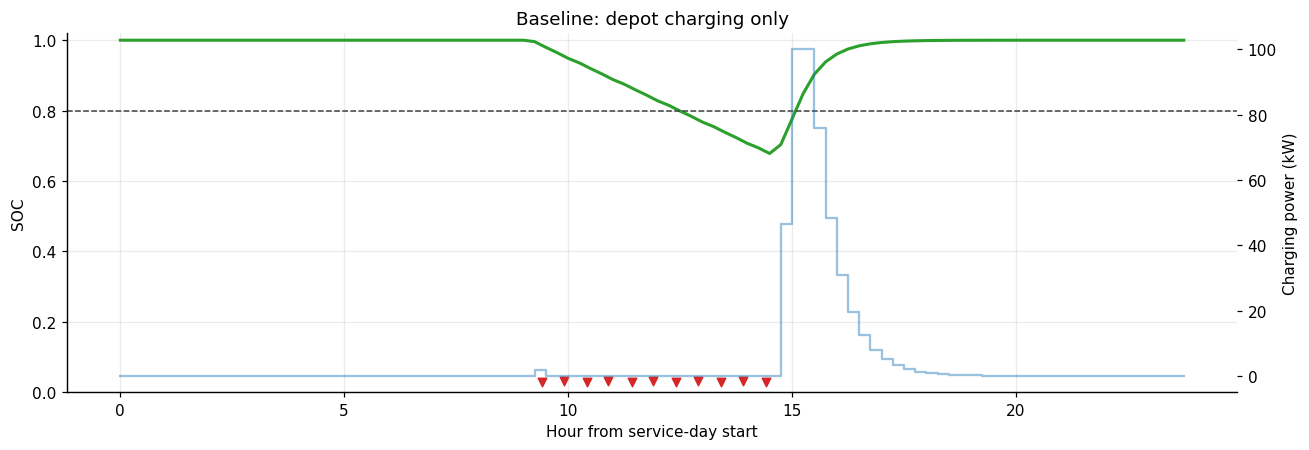

,soc_end,soc_min,energy_charged_kwh,depot_kwh,layover_kwh,total_consumed_kwh
0,1.0,0.678152,114.430509,114.430509,0.0,114.430521


In [61]:
baseline = simulate_block(
    protagonist_block,
    battery_kwh=BUS_BATTERY_KWH,
    consumption_kwh_per_km=BUS_CONSUMPTION_KWH_PER_KM,
    depot_charge_kw=DEPOT_CHARGE_KW,
    allow_layover_charging=False,
)
time_h = np.arange(len(baseline["soc"])) * STEP_HOURS

fig, ax_soc = plt.subplots(figsize=(12, 4.2))
ax_load = ax_soc.twinx()
ax_soc.plot(time_h, baseline["soc"], color="tab:green", lw=2, label="SOC")
ax_load.step(time_h, baseline["load_kw"], where="post", color="tab:blue", alpha=0.45, label="load_kw")
for schedule in baseline["schedules"]:
    offset = schedule.day * 24.0
    for trip in schedule.trips:
        ax_soc.scatter(offset + trip.departure_time, max(0.0, trip.energy_consumed_kwh / BUS_BATTERY_KWH), marker="v", color="tab:red", s=30)
ax_soc.axhline(CV_THRESHOLD[DEFAULT_CHEMISTRY], color="0.25", ls="--", lw=1, label=f"CV threshold {DEFAULT_CHEMISTRY}")
ax_soc.set(xlabel="Hour from service-day start", ylabel="SOC", ylim=(0, 1.02))
ax_load.set_ylabel("Charging power (kW)")
ax_soc.set_title("Baseline: depot charging only")
ax_soc.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(pd.DataFrame([{key: baseline[key] for key in ["soc_end", "soc_min", "energy_charged_kwh", "depot_kwh", "layover_kwh", "total_consumed_kwh"]}]))

## E. What if we charge during layovers

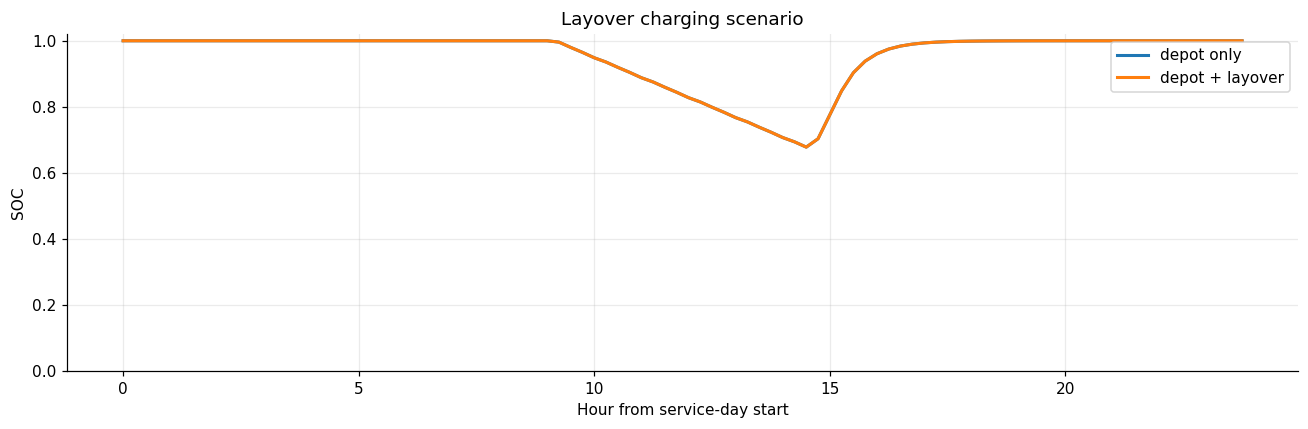

,scenario,soc_end,soc_min,energy_charged_kwh,depot_share
0,depot_only,1.0,0.678152,114.430509,1.0
1,depot_plus_layover,1.0,0.678152,114.430509,1.0


In [62]:
with_layover = simulate_block(
    protagonist_block,
    battery_kwh=BUS_BATTERY_KWH,
    consumption_kwh_per_km=BUS_CONSUMPTION_KWH_PER_KM,
    depot_charge_kw=DEPOT_CHARGE_KW,
    allow_layover_charging=True,
    layover_charge_kw=50.0,
    min_layover_for_charging_h=STEP_HOURS,
)

fig, ax = plt.subplots(figsize=(12, 4.0))
ax.plot(np.arange(len(baseline["soc"])) * STEP_HOURS, baseline["soc"], lw=2, label="depot only")
ax.plot(np.arange(len(with_layover["soc"])) * STEP_HOURS, with_layover["soc"], lw=2, label="depot + layover")
ax.set(xlabel="Hour from service-day start", ylabel="SOC", ylim=(0, 1.02), title="Layover charging scenario")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

compare = pd.DataFrame(
    [
        {
            "scenario": "depot_only",
            "soc_end": baseline["soc_end"],
            "soc_min": baseline["soc_min"],
            "energy_charged_kwh": baseline["energy_charged_kwh"],
            "depot_share": baseline["depot_kwh"] / max(baseline["energy_charged_kwh"], 1e-9),
        },
        {
            "scenario": "depot_plus_layover",
            "soc_end": with_layover["soc_end"],
            "soc_min": with_layover["soc_min"],
            "energy_charged_kwh": with_layover["energy_charged_kwh"],
            "depot_share": with_layover["depot_kwh"] / max(with_layover["energy_charged_kwh"], 1e-9),
        },
    ]
)
display(compare)

## F. Sensitivity grid

,battery_kwh,consumption_kwh_per_km,soc_end,soc_min,below_0_10
0,258.8,0.622,1.000000,0.678902,False
1,258.8,0.830,1.000000,0.571525,False
2,258.8,1.037,1.000000,0.464664,False
3,345.0,0.622,1.000000,0.758808,False
4,345.0,0.830,1.000000,0.678152,False
5,345.0,1.037,1.000000,0.597884,False
6,431.2,0.622,0.999999,0.806869,False
7,431.2,0.830,0.999999,0.742285,False
8,431.2,1.037,0.999998,0.678012,False


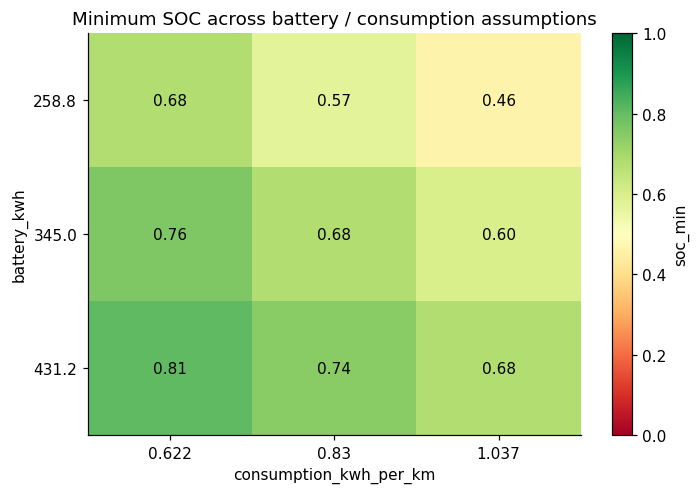

In [63]:
battery_grid = sorted({round(BUS_BATTERY_KWH * factor, 1) for factor in [0.75, 1.0, 1.25]})
consumption_grid = sorted({round(BUS_CONSUMPTION_KWH_PER_KM * factor, 3) for factor in [0.75, 1.0, 1.25]})
rows = []
for battery_kwh in battery_grid:
    for consumption_kwh_per_km in consumption_grid:
        result = simulate_block(
            protagonist_block,
            battery_kwh=battery_kwh,
            consumption_kwh_per_km=consumption_kwh_per_km,
            depot_charge_kw=DEPOT_CHARGE_KW,
            allow_layover_charging=False,
        )
        rows.append(
            {
                "battery_kwh": battery_kwh,
                "consumption_kwh_per_km": consumption_kwh_per_km,
                "soc_end": result["soc_end"],
                "soc_min": result["soc_min"],
                "below_0_10": result["soc_min"] < 0.10,
            }
        )
sensitivity = pd.DataFrame(rows)
display(sensitivity)

heat = sensitivity.pivot(index="battery_kwh", columns="consumption_kwh_per_km", values="soc_min")
fig, ax = plt.subplots(figsize=(6.6, 4.6))
im = ax.imshow(heat.values, vmin=0.0, vmax=1.0, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(heat.columns)), [str(col) for col in heat.columns])
ax.set_yticks(range(len(heat.index)), [str(idx) for idx in heat.index])
ax.set_xlabel("consumption_kwh_per_km")
ax.set_ylabel("battery_kwh")
ax.set_title("Minimum SOC across battery / consumption assumptions")
for i, battery_kwh in enumerate(heat.index):
    for j, consumption in enumerate(heat.columns):
        value = heat.loc[battery_kwh, consumption]
        marker = "!" if value < 0.10 else ""
        ax.text(j, i, f"{value:.2f}{marker}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="soc_min")
plt.tight_layout()
plt.show()

## I. Fleet feasibility and deadhead audit

,metric,value
0,scope,full fleet audit loaded from outputs/bus_feasi...
1,total_blocks,2000
2,infeasible_blocks,228
3,infeasible_pct,11.4
4,deadhead_total_km,3460.46487
5,deadhead_skipped_time_km,4.907626
6,long_deadhead_blocks,52


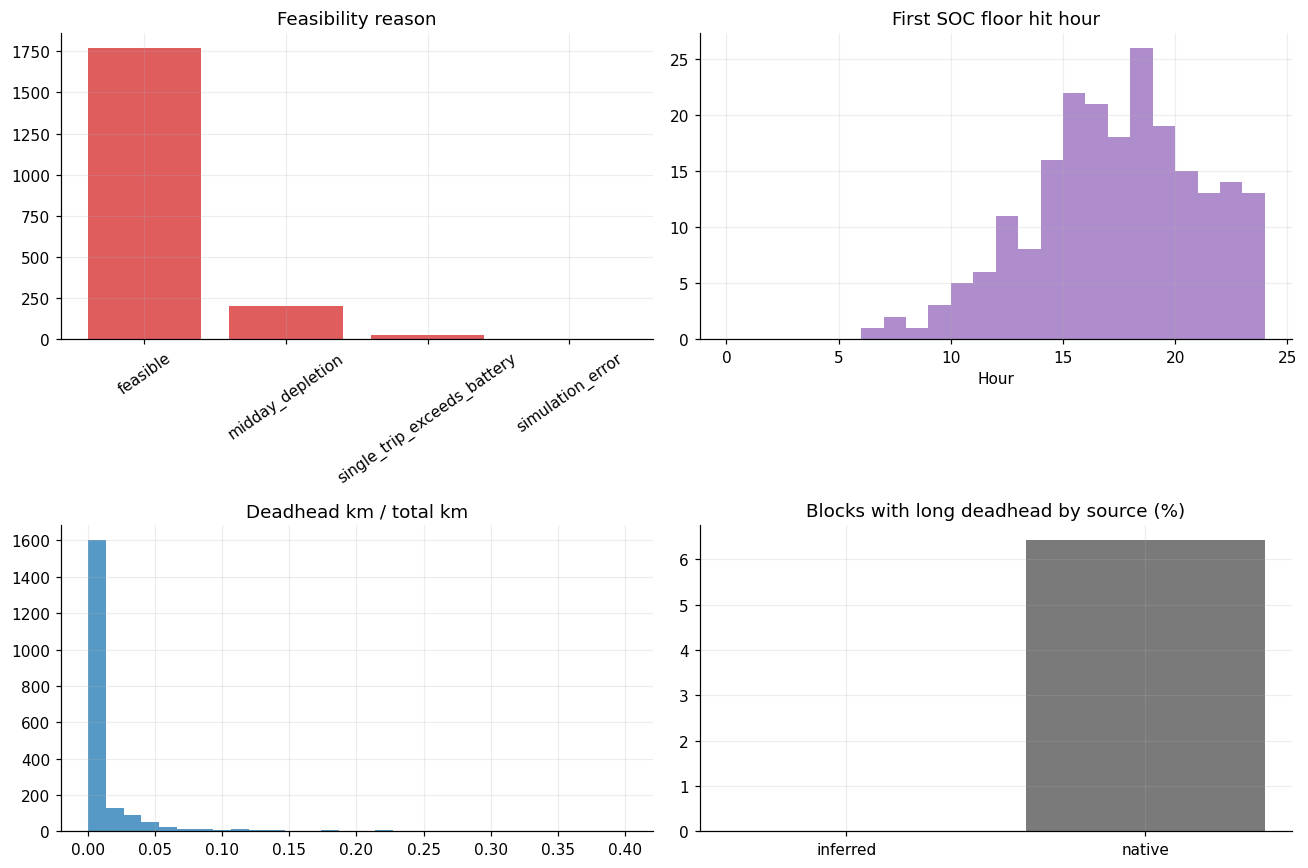

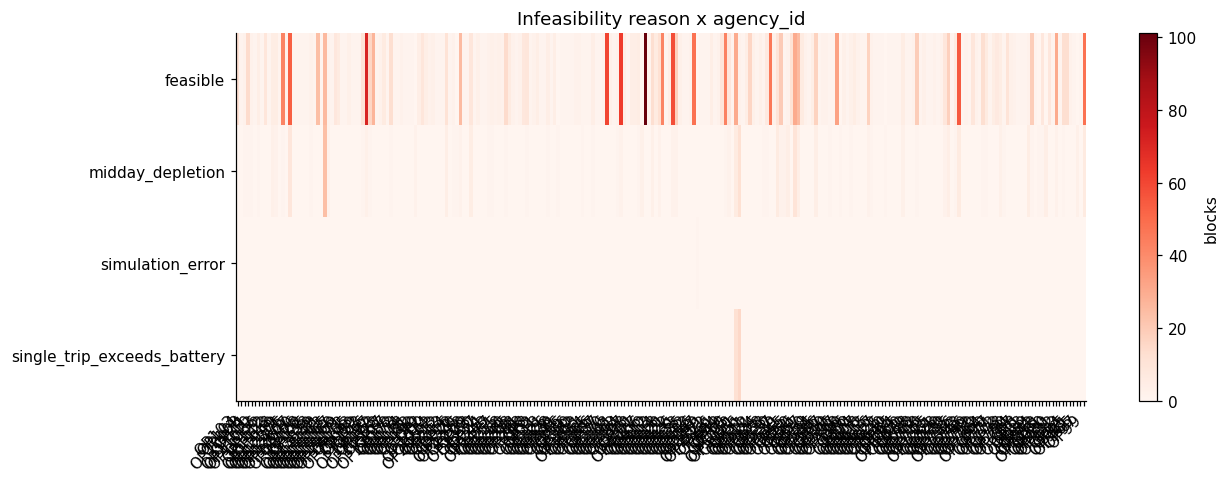

blocks  infeasible  deadhead_km  infeasible_share
agency_id route_id                                                          
OP83      83660                 5           5    82.258963          1.000000
OP14161   7525052               7           5     0.000000          0.714286
          9914917               5           4     2.764193          0.800000
OP12475   132867                4           3     0.000000          0.750000
OP14161   6757257,6757278       4           3     5.934293          0.750000

,spec,battery_kwh,soc_min,infeasible,shortfall_kwh,reason,deadhead_total_km,deadhead_skipped_time_km
0,sampled default,345.0,0.678152,False,0.0,None,0.0,0.0
1,BYD EBUS 345 kWh,345.0,0.678152,False,0.0,None,0.0,0.0
2,small battery 180 kWh,180.0,0.385391,False,0.0,None,0.0,0.0


In [64]:
if AUDIT_PATH.exists():
    audit = pd.read_parquet(AUDIT_PATH)
    audit_scope = "full fleet audit loaded from outputs/bus_feasibility_audit.parquet"
else:
    audit_scope = "deterministic sample audit, not full fleet"
    block_catalog = all_blocks.groupby("block_id", sort=False)["block_source"].first().reset_index()
    sample_ids = (
        block_catalog.groupby("block_source", group_keys=False)
        .apply(lambda frame: frame.sample(n=min(20, len(frame)), random_state=MAIN_BUS_SEED))
        ["block_id"]
        .tolist()
    )
    audit_blocks = all_blocks[all_blocks["block_id"].isin(sample_ids)].copy()
    audit, _audit_load = simulate_fleet_blocks(
        audit_blocks,
        battery_kwh=BUS_BATTERY_KWH,
        consumption_kwh_per_km=BUS_CONSUMPTION_KWH_PER_KM,
        depot_charge_kw=DEPOT_CHARGE_KW,
        allow_layover_charging=False,
    )
    audit = audit.reset_index()

block_lookup = all_blocks.groupby("block_id", sort=False).agg(
    route_id=("route_id", lambda values: ",".join(sorted({str(v) for v in values})[:3])),
    agency_id=("agency_id", "first"),
    block_source=("block_source", "first"),
    service_total_km=("distance_km", "sum"),
).reset_index()
audit = audit.merge(block_lookup, on="block_id", how="left", suffixes=("", "_blocks"))
if "agency_id_blocks" in audit:
    audit["agency_id"] = audit["agency_id"].fillna(audit["agency_id_blocks"])
if "block_source_blocks" in audit:
    audit["block_source"] = audit["block_source"].fillna(audit["block_source_blocks"])
audit["deadhead_share"] = audit["deadhead_total_km"] / audit["total_km"].replace(0.0, np.nan)

summary = pd.DataFrame(
    [
        ("scope", audit_scope),
        ("total_blocks", int(len(audit))),
        ("infeasible_blocks", int(audit["infeasible"].fillna(False).sum())),
        ("infeasible_pct", float(audit["infeasible"].fillna(False).mean() * 100.0) if len(audit) else np.nan),
        ("deadhead_total_km", float(audit["deadhead_total_km"].sum())),
        ("deadhead_skipped_time_km", float(audit["deadhead_skipped_time_km"].sum())),
        ("long_deadhead_blocks", int((audit["deadhead_long_count"] > 0).sum())),
    ],
    columns=["metric", "value"],
)
display(summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
reason_counts = audit["infeasibility_reason"].fillna("feasible").value_counts()
axes[0, 0].bar(reason_counts.index.astype(str), reason_counts.values, color="tab:red", alpha=0.75)
axes[0, 0].set_title("Feasibility reason")
axes[0, 0].tick_params(axis="x", rotation=35)
floor_h = pd.to_numeric(audit["first_floor_hit_h"], errors="coerce").dropna()
axes[0, 1].hist(floor_h, bins=np.arange(0, 25, 1), color="tab:purple", alpha=0.75)
axes[0, 1].set_title("First SOC floor hit hour")
axes[0, 1].set_xlabel("Hour")
axes[1, 0].hist(audit["deadhead_share"].dropna(), bins=30, color="tab:blue", alpha=0.75)
axes[1, 0].set_title("Deadhead km / total km")
long_by_source = audit.groupby("block_source")["deadhead_long_count"].apply(lambda s: float((s > 0).mean() * 100.0))
axes[1, 1].bar(long_by_source.index.astype(str), long_by_source.values, color="0.35", alpha=0.8)
axes[1, 1].set_title("Blocks with long deadhead by source (%)")
for ax in axes.ravel():
    ax.grid(alpha=0.22)
plt.tight_layout()
plt.show()

reason_agency = pd.crosstab(
    audit["infeasibility_reason"].fillna("feasible"),
    audit["agency_id"].astype(str),
)
if not reason_agency.empty:
    fig, ax = plt.subplots(figsize=(min(12, 2 + 0.5 * reason_agency.shape[1]), 4.5))
    im = ax.imshow(reason_agency.values, aspect="auto", cmap="Reds")
    ax.set_yticks(range(reason_agency.shape[0]), reason_agency.index)
    ax.set_xticks(range(reason_agency.shape[1]), reason_agency.columns, rotation=45, ha="right")
    ax.set_title("Infeasibility reason x agency_id")
    fig.colorbar(im, ax=ax, label="blocks")
    plt.tight_layout()
    plt.show()

route_rank = audit.groupby(["agency_id", "route_id"], dropna=False).agg(
    blocks=("block_id", "count"),
    infeasible=("infeasible", "sum"),
    deadhead_km=("deadhead_total_km", "sum"),
)
route_rank["infeasible_share"] = route_rank["infeasible"] / route_rank["blocks"].clip(lower=1)
display(route_rank.sort_values(["infeasible", "infeasible_share"], ascending=False).head(5))

spec_rows = []
for label, battery_kwh, consumption_kwh_per_km in [
    ("sampled default", BUS_BATTERY_KWH, BUS_CONSUMPTION_KWH_PER_KM),
    ("BYD EBUS 345 kWh", 345.0, BUS_CONSUMPTION_KWH_PER_KM),
    ("small battery 180 kWh", 180.0, BUS_CONSUMPTION_KWH_PER_KM),
]:
    result = simulate_block(
        protagonist_block,
        battery_kwh=battery_kwh,
        consumption_kwh_per_km=consumption_kwh_per_km,
        depot_charge_kw=DEPOT_CHARGE_KW,
        allow_layover_charging=False,
    )
    spec_rows.append(
        {
            "spec": label,
            "battery_kwh": battery_kwh,
            "soc_min": result["soc_min"],
            "infeasible": result["infeasible"],
            "shortfall_kwh": result["shortfall_kwh"],
            "reason": result["infeasibility_reason"],
            "deadhead_total_km": result["deadhead_total_km"],
            "deadhead_skipped_time_km": result["deadhead_skipped_time_km"],
        }
    )
display(pd.DataFrame(spec_rows))

## H. Final identity card

In [65]:
dwell_by_purpose = parking_table.groupby("purpose")["duration_h"].sum()
final_card = pd.DataFrame(
    [
        {
            "block_id": protagonist_id,
            "agency_id": str(protagonist_block["agency_id"].iloc[0]),
            "n_trips_original": int(protagonist_block.shape[0]),
            "n_schedule_days": len(baseline["schedules"]),
            "total_km": round(baseline["total_km"], 2),
            "span_h": round(float(protagonist_block["end_h"].max() - protagonist_block["start_h"].min()), 2),
            "vehicle_make": protagonist_vehicle["make"],
            "vehicle_gen_model": protagonist_vehicle["gen_model"],
            "vehicle_stock_2025_q2": float(protagonist_vehicle["stock_2025_q2"]),
            "first_origin_lsoa": str(trips_table["origin_lsoa"].iloc[0]) if not trips_table.empty else "",
            "last_destination_lsoa": str(trips_table["destination_lsoa"].iloc[-1]) if not trips_table.empty else "",
            "depot_dwell_h": round(float(dwell_by_purpose.get("depot_terminus", 0.0)), 2),
            "layover_dwell_h": round(float(dwell_by_purpose.get("layover", 0.0)), 2),
            "total_consumed_kwh": round(baseline["total_consumed_kwh"], 2),
            "battery_kwh": BUS_BATTERY_KWH,
            "consumption_kwh_per_km": BUS_CONSUMPTION_KWH_PER_KM,
            "depot_charge_kw": DEPOT_CHARGE_KW,
            "soc_end_baseline": round(baseline["soc_end"], 4),
            "soc_min_baseline": round(baseline["soc_min"], 4),
            "soc_end_with_layover": round(with_layover["soc_end"], 4),
            "energy_charged_kwh_baseline": round(baseline["energy_charged_kwh"], 2),
        }
    ]
).T.rename(columns={0: "value"})
display(final_card)

print(f"Notebook runtime: {time.time() - NOTEBOOK_START:.1f}s")

,value
block_id,96ecdc100da3a3a41b0b5d57e89d4ae12380c450
agency_id,OP393
n_trips_original,11
n_schedule_days,1
total_km,137.87
span_h,5.47
vehicle_make,BYD
vehicle_gen_model,BYD EBUS
vehicle_stock_2025_q2,180.0
first_origin_lsoa,E01021490


Notebook runtime: 24.8s


## J. M1 chain-mode diagnostics

These cells read the M1 pipeline outputs produced by `scripts/run_bus_pipeline.py`. They do not write parquet or CSV files.


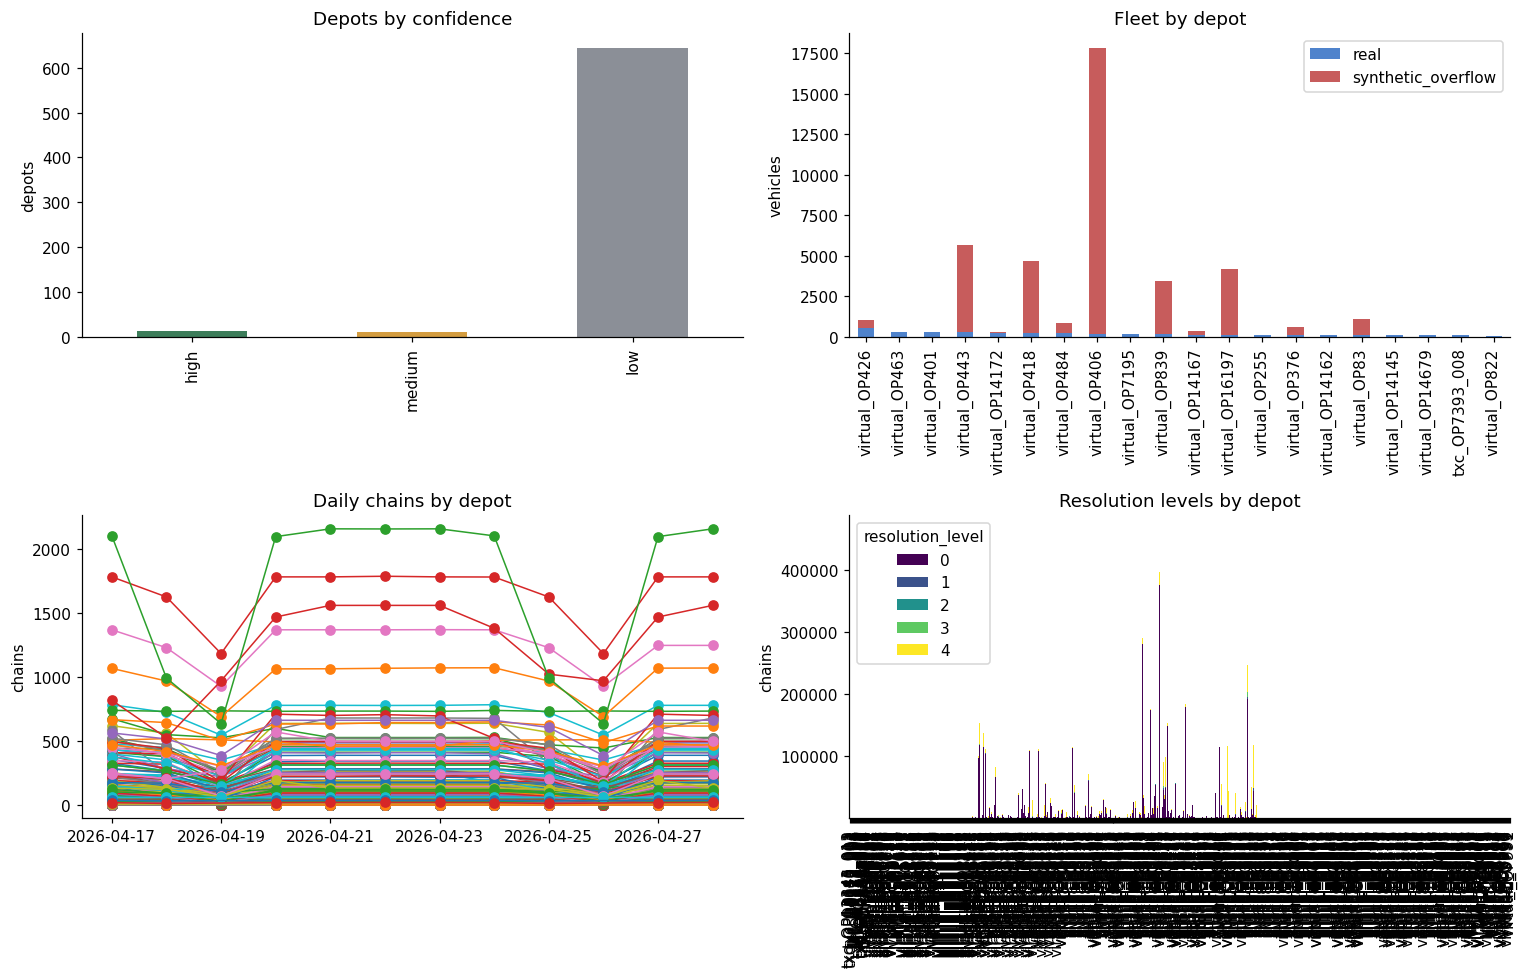

In [66]:

M1_OUTPUT_DIR = REPO_ROOT / "outputs"
if not (M1_OUTPUT_DIR / "resolution_summary.parquet").exists() and (M1_OUTPUT_DIR / "m1_smoke" / "resolution_summary.parquet").exists():
    M1_OUTPUT_DIR = M1_OUTPUT_DIR / "m1_smoke"

m1_paths = {
    "depot_registry": M1_OUTPUT_DIR / "depot_registry.parquet",
    "vehicles": M1_OUTPUT_DIR / "vehicles.parquet",
    "vehicle_assignments": M1_OUTPUT_DIR / "vehicle_assignments.parquet",
    "vehicle_day_events": M1_OUTPUT_DIR / "vehicle_day_events.parquet",
    "resolution_summary": M1_OUTPUT_DIR / "resolution_summary.parquet",
}
missing_m1 = [name for name, path in m1_paths.items() if not path.exists()]

if missing_m1:
    display(pd.DataFrame({"missing_m1_output": missing_m1, "expected_dir": str(M1_OUTPUT_DIR)}))
else:
    depot_registry_m1 = pd.read_parquet(m1_paths["depot_registry"])
    vehicles_m1 = pd.read_parquet(m1_paths["vehicles"])
    assignments_m1 = pd.read_parquet(m1_paths["vehicle_assignments"])
    events_m1 = pd.read_parquet(m1_paths["vehicle_day_events"])
    resolution_m1 = pd.read_parquet(m1_paths["resolution_summary"])

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    depot_counts = depot_registry_m1["depot_confidence"].value_counts().reindex(["high", "medium", "low"]).fillna(0)
    depot_counts.plot(kind="bar", ax=axes[0, 0], color=["#3c7d5a", "#d39c3f", "#8b8f97"])
    axes[0, 0].set_title("Depots by confidence")
    axes[0, 0].set_xlabel("")
    axes[0, 0].set_ylabel("depots")

    real_fleet = vehicles_m1.dropna(subset=["depot_id"]).groupby("depot_id").size().rename("real")
    overflow_fleet = (
        assignments_m1[assignments_m1["vehicle_provenance"].eq("synthetic_overflow")]
        .groupby("depot_id")["vehicle_id"]
        .nunique()
        .rename("synthetic_overflow")
    )
    fleet_by_depot = pd.concat([real_fleet, overflow_fleet], axis=1).fillna(0).sort_values("real", ascending=False).head(20)
    fleet_by_depot.plot(kind="bar", stacked=True, ax=axes[0, 1], color=["#4f83cc", "#c75c5c"])
    axes[0, 1].set_title("Fleet by depot")
    axes[0, 1].set_xlabel("")
    axes[0, 1].set_ylabel("vehicles")

    daily_chains = (
        assignments_m1[["service_date", "depot_id", "chain_id"]]
        .drop_duplicates()
        .groupby(["service_date", "depot_id"])
        .size()
        .rename("chains")
        .reset_index()
    )
    for depot_id, group in daily_chains.groupby("depot_id"):
        axes[1, 0].plot(pd.to_datetime(group["service_date"]), group["chains"], marker="o", linewidth=1, label=str(depot_id)[:24])
    axes[1, 0].set_title("Daily chains by depot")
    axes[1, 0].set_xlabel("")
    axes[1, 0].set_ylabel("chains")
    if daily_chains["depot_id"].nunique() <= 8:
        axes[1, 0].legend(fontsize=8)

    resolution_mix = (
        resolution_m1.groupby(["depot_id", "resolution_level"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    resolution_mix.plot(kind="bar", stacked=True, ax=axes[1, 1], colormap="viridis")
    axes[1, 1].set_title("Resolution levels by depot")
    axes[1, 1].set_xlabel("")
    axes[1, 1].set_ylabel("chains")

    plt.tight_layout()
    plt.show()


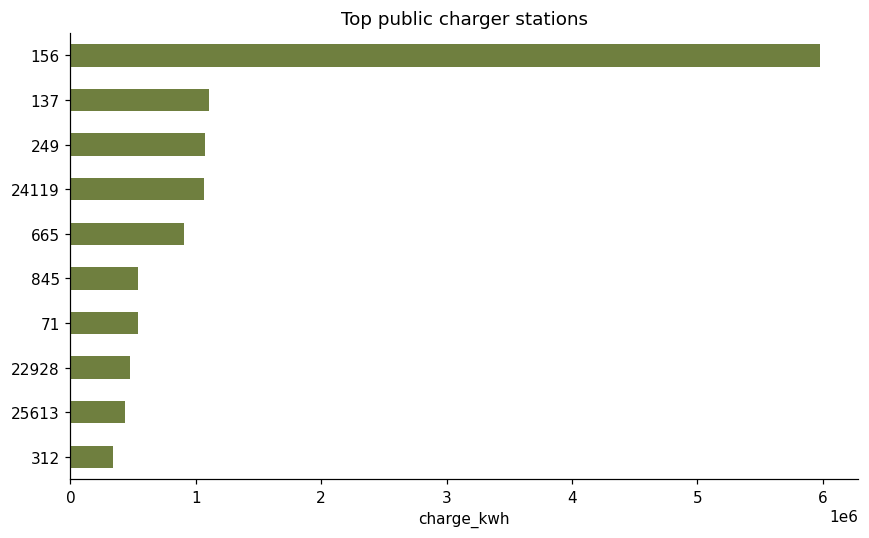

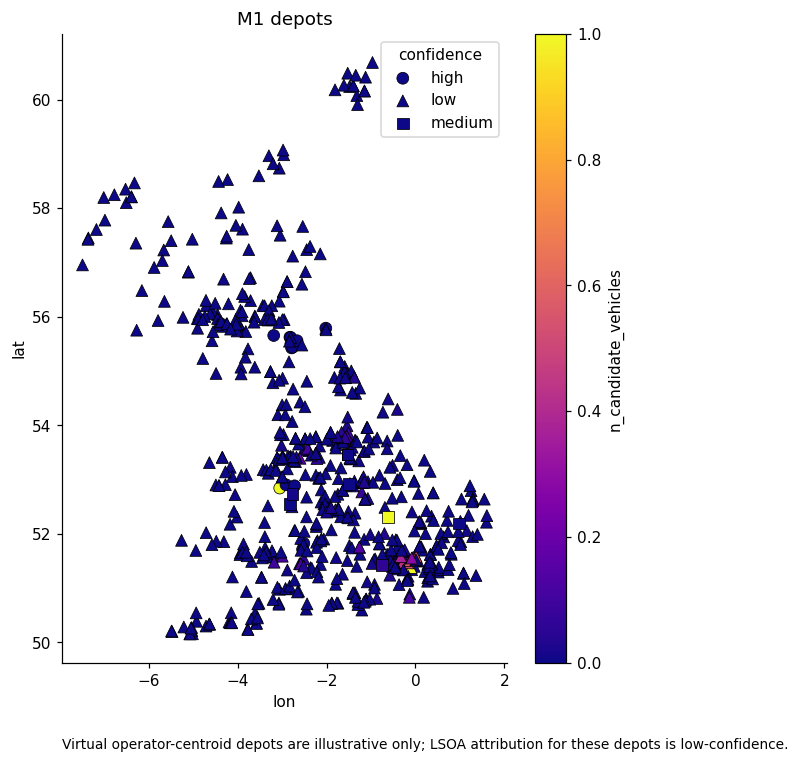

In [67]:

if not missing_m1:
    station_rows = []
    for row in resolution_m1.itertuples(index=False):
        stations = [station for station in str(row.station_ids_used_csv).split(",") if station and not station.startswith("depot_")]
        if not stations:
            continue
        share = float(row.opportunity_charge_kwh) / len(stations) if stations else 0.0
        station_rows.extend({"station_id": station, "charge_kwh": share} for station in stations)
    station_charge = pd.DataFrame(station_rows)
    if station_charge.empty:
        display(pd.DataFrame({"public_charger_station": [], "charge_kwh": []}))
    else:
        top_public = station_charge.groupby("station_id", as_index=False)["charge_kwh"].sum().nlargest(10, "charge_kwh")
        ax = top_public.plot(kind="barh", x="station_id", y="charge_kwh", figsize=(8, 5), legend=False, color="#6f7f3f")
        ax.invert_yaxis()
        ax.set_xlabel("charge_kwh")
        ax.set_ylabel("")
        ax.set_title("Top public charger stations")
        plt.tight_layout()
        plt.show()

    fig, ax = plt.subplots(figsize=(7, 7))
    marker_by_confidence = {"high": "o", "medium": "s", "low": "^"}
    for confidence, group in depot_registry_m1.groupby("depot_confidence"):
        ax.scatter(
            group["lon"],
            group["lat"],
            s=60,
            marker=marker_by_confidence.get(confidence, "x"),
            c=group["n_candidate_vehicles"],
            cmap="plasma",
            edgecolor="black",
            linewidth=0.5,
            label=confidence,
        )
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    ax.set_title("M1 depots")
    ax.legend(title="confidence")
    fig.colorbar(ax.collections[0], ax=ax, label="n_candidate_vehicles")
    ax.text(
        0.0,
        -0.12,
        "Virtual operator-centroid depots are illustrative only; LSOA attribution for these depots is low-confidence.",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
    )
    plt.tight_layout()
    plt.show()
